In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing, Understanding, and Inspecting Data:
1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.
2. Based on the findings from the previous questions, identify duplicates and remove them

In [148]:
data = pd.read_excel("data.xlsx")
country = pd.read_excel("Country-Code.xlsx")

In [149]:
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243


In [150]:
print(data.shape)
print(data.info())
data.describe()

(9551, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate 

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [151]:
# Null Values
print(data.isnull().sum())
print(data.isnull().sum().sum())

Restaurant ID           0
Restaurant Name         1
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64
10


In [152]:
print(data["Restaurant Name"].isnull().sum())
print(data["Cuisines"].isnull().sum())

1
9


In [153]:
# Duplicate Values
print(data.duplicated().sum())

0


In [154]:
data["Restaurant Name"] = data["Restaurant Name"].fillna("Unknown Restaurant")
data["Cuisines"] = data["Cuisines"].fillna("Other")

In [155]:
data.drop(columns= ["Locality Verbose"], inplace= True)

In [156]:
# Removing all the rows with 0 Average Cost for two

data = data[data["Average Cost for two"] > 0] 

In [157]:
# After cleaning the data
# There are no null values and unwanted columns

In [158]:
print(data.info())
print(data.shape)
print(data.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 9533 entries, 0 to 9532
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9533 non-null   int64  
 1   Restaurant Name       9533 non-null   object 
 2   Country Code          9533 non-null   int64  
 3   City                  9533 non-null   object 
 4   Address               9533 non-null   object 
 5   Locality              9533 non-null   object 
 6   Longitude             9533 non-null   float64
 7   Latitude              9533 non-null   float64
 8   Cuisines              9533 non-null   object 
 9   Average Cost for two  9533 non-null   int64  
 10  Currency              9533 non-null   object 
 11  Has Table booking     9533 non-null   object 
 12  Has Online delivery   9533 non-null   object 
 13  Price range           9533 non-null   int64  
 14  Aggregate rating      9533 non-null   float64
 15  Rating color          9533

### Performing EDA:  

3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants
4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence
5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking
6. Find out the percentage of restaurants providing online delivery
7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [159]:
# Merging the tables.
data = pd.merge(data, country, on="Country Code", how="left")
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,Indonesia


#### 3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants

In [160]:
city_counts = data["City"].value_counts()
print(city_counts)

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Consort              1
Lincoln              1
Monroe               1
Potrero              1
Lakes Entrance       1
Name: count, Length: 140, dtype: int64


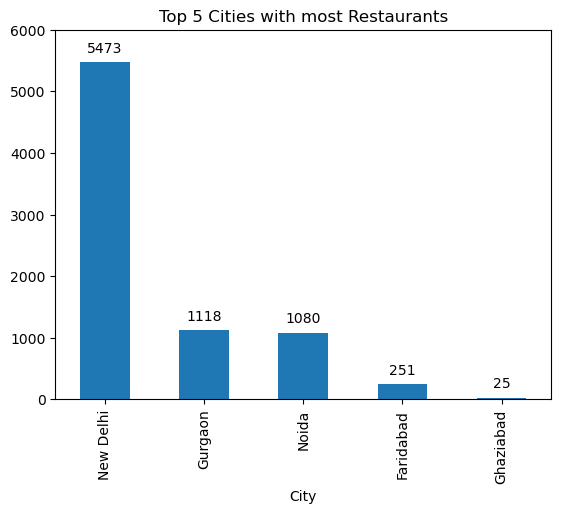

('New Delhi', 'Penola')

In [161]:
ax_city_counts = city_counts.head(5).plot(kind= "bar")
ax_city_counts.bar_label(ax_city_counts.containers[0], padding= 5)
plt.ylim(0, 6000)
plt.title("Top 5 Cities with most Restaurants")
plt.show()

# Min and Max
city_counts.idxmax(), city_counts.idxmin()

#### 4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence

In [162]:
# Franchise means One single restaurant having multiple outlets with the same name

chain = data["Restaurant Name"].value_counts()

franchise = chain[chain>1]
print(franchise.head(10))

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


#### 5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking

Has Table booking
No     87.852722
Yes    12.147278
Name: proportion, dtype: float64


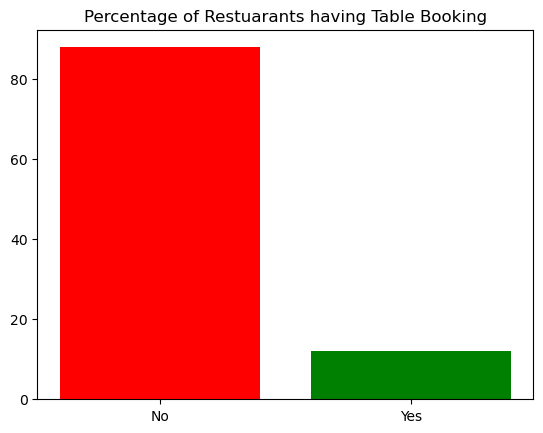

In [163]:
table_booking = data["Has Table booking"].value_counts(normalize= True)*100
print(table_booking)

plt.bar(table_booking.index, table_booking, color = ["red", "green"])
plt.title("Percentage of Restuarants having Table Booking") 
plt.show()

#### 6. Find out the percentage of restaurants providing online delivery

Has Online delivery
No     74.289311
Yes    25.710689
Name: proportion, dtype: float64


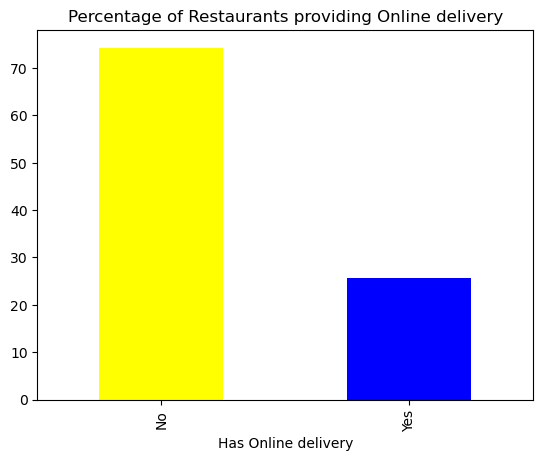

In [164]:
online_delivery = data["Has Online delivery"].value_counts(normalize= True)*100
print(online_delivery)

online_delivery.plot(kind= "bar", color = ["yellow", "blue"])
plt.title("Percentage of Restaurants providing Online delivery")
plt.show()

#### 7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

Has Online delivery
No     138.278594
Yes    211.307222
Name: Votes, dtype: float64


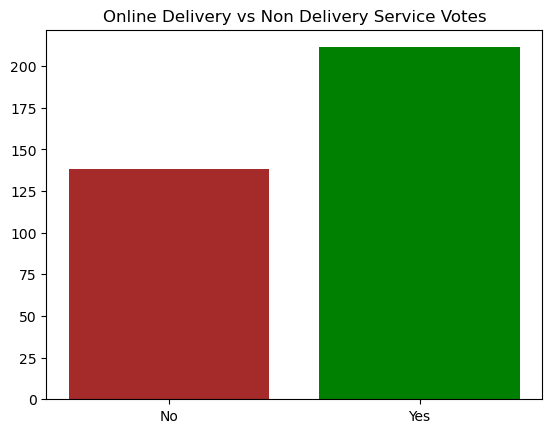

In [165]:
delivery_votes = data.groupby("Has Online delivery")["Votes"].mean()
print(delivery_votes)

plt.bar(delivery_votes.index, delivery_votes, color= ["brown", "green"])
plt.title("Online Delivery vs Non Delivery Service Votes")
plt.show()

### Performing EDA:
1. What are the top 10 cuisines served across cities?
2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?
3. What is the distribution cost across the restaurants?
4. How ratings are distributed among the various factors?
5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

#### 1. What are the top 10 cuisines served across cities?

In [166]:
cuisines_exploded = data["Cuisines"].str.split(",").explode().str.strip()

top10_cuisines = cuisines_exploded.value_counts().head(10)
print(top10_cuisines)

Cuisines
North Indian    3954
Chinese         2729
Fast Food       1985
Mughlai          995
Italian          760
Bakery           745
Continental      732
Cafe             700
Desserts         651
South Indian     636
Name: count, dtype: int64


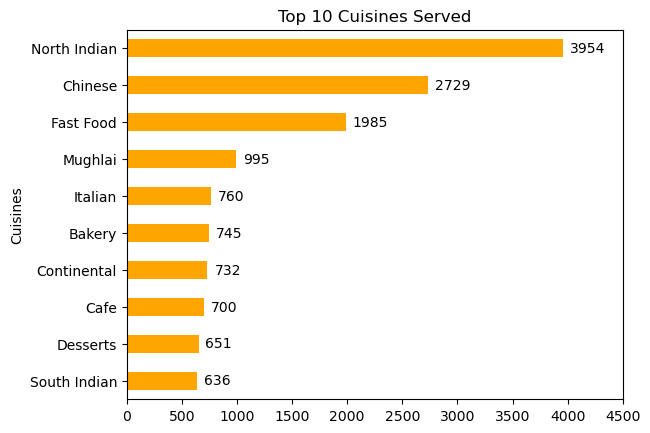

In [167]:
ax_top10_cuisines = top10_cuisines.sort_values().plot(kind= "barh", color= "orange")
ax_top10_cuisines.bar_label(ax_top10_cuisines.containers[0], padding= 5)
plt.xlim(0, 4500)
plt.title("Top 10 Cuisines Served")
plt.show()

#### 2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?

In [168]:
data["Cuisine_Count"] = data["Cuisines"].str.split(",").str.len()

print(data['Cuisine_Count'].describe())

# OR

print(data["Cuisine_Count"].max())
print(data["Cuisine_Count"].min())

count    9533.000000
mean        2.064093
std         1.091965
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: Cuisine_Count, dtype: float64
8
1


In [169]:
data['Cuisine_List'] = data['Cuisines'].str.split(', ')
data_exploded = data.explode('Cuisine_List')

cuisine_counts = data_exploded.groupby(['City', 'Cuisine_List']).size().reset_index(name='Count')
cuisine_counts = cuisine_counts.sort_values(['City', 'Count'], ascending=[True, False])

most_served_cuisine = cuisine_counts.drop_duplicates('City')
print(most_served_cuisine[['City', 'Cuisine_List', 'Count']].head(10))

          City  Cuisine_List  Count
11   Abu Dhabi        Indian      7
35        Agra  North Indian     12
46   Ahmedabad   Continental     12
60      Albany      American      4
89   Allahabad  North Indian     11
102   Amritsar  North Indian     15
111     Ankara         Kebab     10
118   Armidale      Bar Food      1
120     Athens      American      5
143   Auckland          Cafe      5


#### 3. What is the distribution cost across the restaurants?

In [170]:
data["Currency"].unique()

array(['Indonesian Rupiah(IDR)', 'Indian Rupees(Rs.)', 'Botswana Pula(P)',
       'Sri Lankan Rupee(LKR)', 'Rand(R)', 'Qatari Rial(QR)', 'Dollar($)',
       'Emirati Diram(AED)', 'Brazilian Real(R$)', 'Turkish Lira(TL)',
       'Pounds(å£)', 'NewZealand($)'], dtype=object)

In [171]:
# Simple Exchange Rate Dictionary (Local Currency per 1 USD)

rates = {
    'Indian Rupees(Rs.)': 83.0,
    'Indonesian Rupiah(IDR)': 15800.0,
    'Brazilian Real(R$)': 5.0,
    'Turkish Lira(TL)': 32.0,
    'Emirati Diram(AED)': 3.67,
    'Pounds(å£)': 0.79,
    'Qatari Rial(QR)': 3.64,
    'Rand(R)': 19.0,
    'Sri Lankan Rupee(LKR)': 300.0,
    'NewZealand($)': 1.6,
    'Botswana Pula(P)': 13.7,
    'Dollar($)': 1.0 
}

conversion_rate = data['Currency'].map(rates)
data.loc[:, "Average_Cost_USD"] = data["Average Cost for two"] // conversion_rate

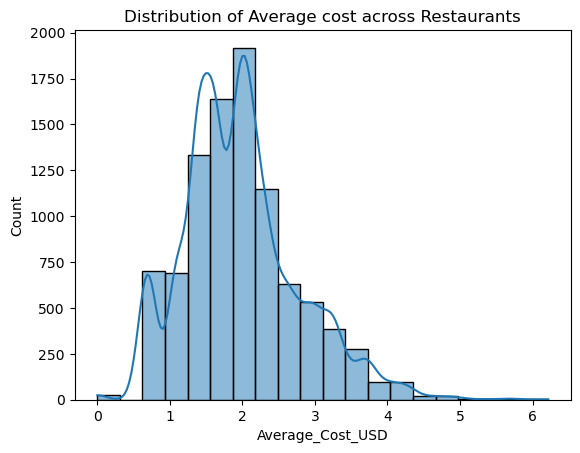

In [172]:
sns.histplot(np.log1p(data["Average_Cost_USD"]), bins= 20, kde= True)
plt.title("Distribution of Average cost across Restaurants")
plt.show()

#### 4. How ratings are distributed among the various factors?

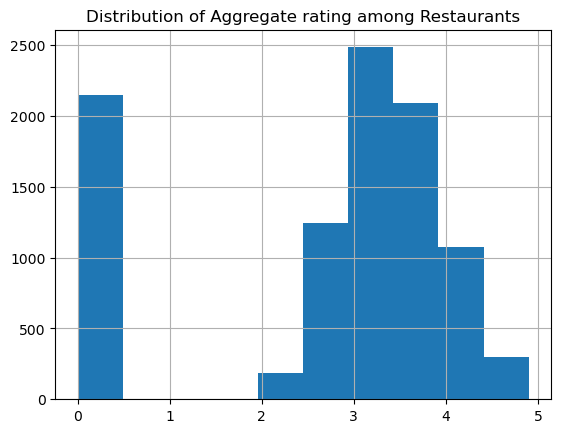

In [173]:
data["Aggregate rating"].hist()
plt.title("Distribution of Aggregate rating among Restaurants")
plt.show()

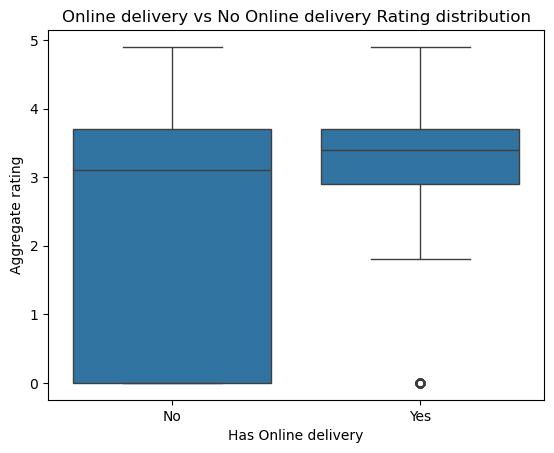

In [174]:
sns.boxplot(data = data, x = 'Has Online delivery', y = 'Aggregate rating')
plt.title("Online delivery vs No Online delivery Rating distribution")
plt.show()

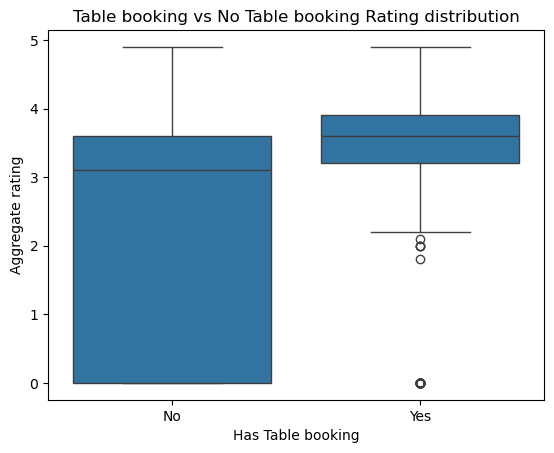

In [175]:
sns.boxplot(data = data, x = 'Has Table booking', y = 'Aggregate rating')
plt.title("Table booking vs No Table booking Rating distribution")
plt.show()

#### 5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

Text(0.5, 1.0, 'Correlation Heatmap: Factors Affecting Ratings')

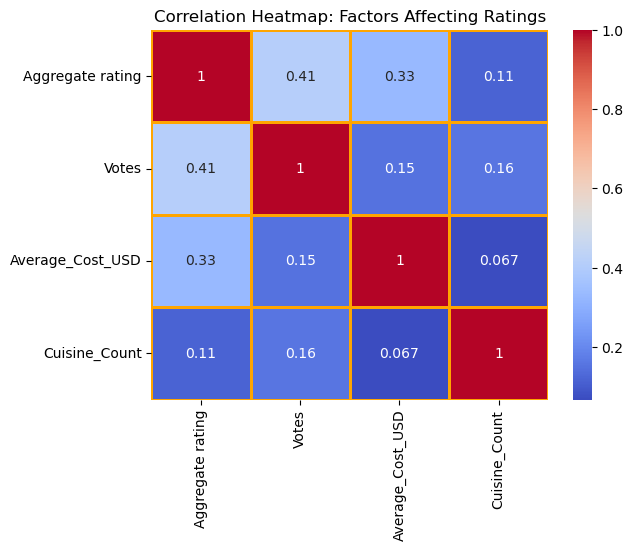

In [176]:
data_copy = data.copy()
data_copy = data_copy[data_copy["Aggregate rating"] > 0]

corr_columns = ["Aggregate rating", "Votes", "Average_Cost_USD", "Cuisine_Count"]

sns.heatmap(data = data_copy[corr_columns].corr(), annot= True, linewidths= 2, linecolor= "orange", cmap= "coolwarm")
plt.title("Correlation Heatmap: Factors Affecting Ratings")

### Final Observation -

1. The data reveals that the B2C portal needs to add more Restaurants offering features and options such as Table Booking and Online delivery because such Restaurannts are likely to get more ratings and votes from the customers
2. This will lead to higher order rate and engagement by the customers with the B2C portal because customers prefer convenience while looking for star restaurants
3. The analysis identifies that Customers generally prefer low to mid range restaurants often giving them higher votes and rating indicating that expensive does not instantly equal to high ratings and votes
4. The B2C portal should focus on adding more such Restaurants along with few high end restaurants for customer satisfaction
5. New Delhi, India is the primary market with over 5,400 Restaurants active
6. This evidence suggests that it is seen as the most sucessful city to operate restaurants
7. Analysis explains that North Indian cuisine is the most dominated and served cuisine across all restaurants globally

In [177]:
# Replacing 0s in Latitude and Longitude with np.nan for analysis in Tableau

data["Longitude"] = data["Longitude"].replace(0, np.nan)
data["Latitude"] = data["Latitude"].replace(0, np.nan)

In [68]:
# Exporting the updated data

data.to_excel("Cleaned_data_and_country.xlsx", index= False)